In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import heapq
import random
import math

In [5]:
img = Image.open("maze2.png").convert("L")
grid = np.array(img)

# 0 = свободно, 1 = стена
threshold = 127
grid = np.where(grid < threshold, 1, 0)

In [9]:
#cтарт и цель
start = (4, 4)
goal = (167, 207)

height, width = grid.shape

free_points = np.argwhere(grid == 0)

# RRT алгоритм

RRT найден путь: True


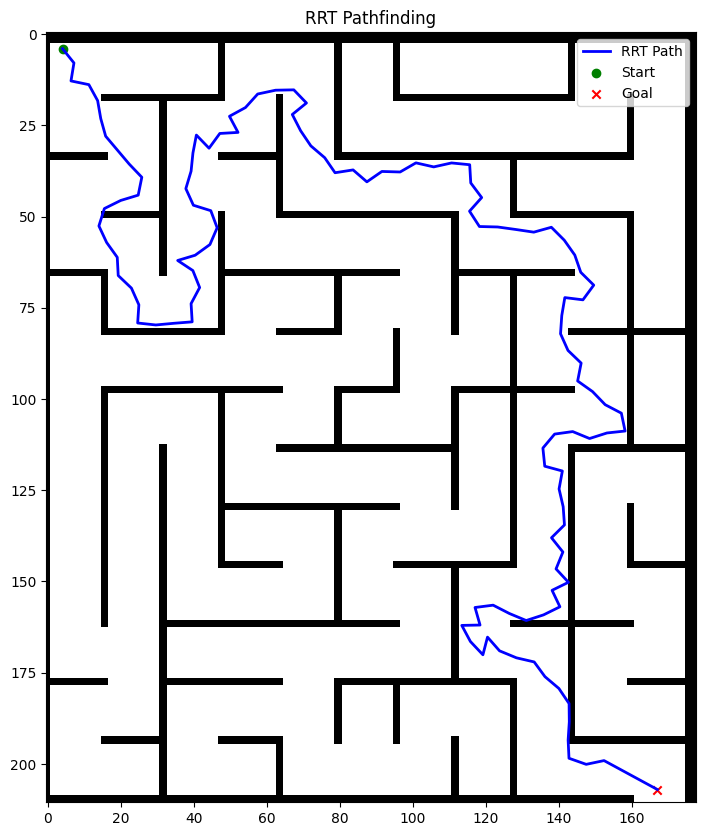

In [29]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random
import math

class RRTNode:
    def __init__(self, x, y, parent=None):
        self.x = x
        self.y = y
        self.parent = parent

# проверка коллизий
def collision_point(x, y):
    if x < 0 or y < 0 or x >= width or y >= height:
        return True
    return grid[int(y)][int(x)] == 1

def collision_line(x1, y1, x2, y2):
    steps = int(max(abs(x2 - x1), abs(y2 - y1)))
    if steps == 0:
        return collision_point(int(x1), int(y1))
    for i in range(steps + 1):
        t = i / steps
        x = x1 + (x2 - x1) * t
        y = y1 + (y2 - y1) * t
        if collision_point(int(x), int(y)):
            return True
    return False

# RRT алгоритм
def rrt(start, goal, max_iter=30000, step_size=10, goal_sample_rate=0.1):
    tree = [RRTNode(start[0], start[1])]
    path = []
    for i in range(max_iter):
        # случайная точка
        if random.random() < goal_sample_rate:
            rnd = goal
        else:
            rnd_y, rnd_x = free_points[random.randint(0, len(free_points)-1)]
            rnd = (rnd_x, rnd_y)

        # ближайшая вершина
        nearest = min(tree, key=lambda node: math.hypot(node.x - rnd[0], node.y - rnd[1]))

        # направление и новый узел
        theta = math.atan2(rnd[1] - nearest.y, rnd[0] - nearest.x)
        new_x = nearest.x + step_size * math.cos(theta)
        new_y = nearest.y + step_size * math.sin(theta)

        # проверка столкновения
        if collision_line(nearest.x, nearest.y, new_x, new_y):
            continue

        new_node = RRTNode(new_x, new_y, nearest)
        tree.append(new_node)
        path.append((new_x, new_y))


        # проверка достижения цели
        if math.hypot(new_x - goal[0], new_y - goal[1]) < step_size:
            if not collision_line(new_x, new_y, goal[0], goal[1]):
                goal_node = RRTNode(goal[0], goal[1], new_node)
                path = []
                current = goal_node
                while current:
                    path.append((current.x, current.y))
                    current = current.parent
                return path[::-1], i
    return path

path_rrt, rrt_iter = rrt(start, goal, step_size=5)

print("RRT найден путь:", path_rrt is not None)

plt.figure(figsize=(10,10))
plt.imshow(grid, cmap='gray_r')

# RRT путь
if path_rrt:
    px, py = zip(*path_rrt)
    plt.plot(px, py, "-b", label="RRT Path", linewidth=2)

plt.scatter(start[0], start[1], marker="o", color="green", label="Start")
plt.scatter(goal[0], goal[1], marker="x", color="red", label="Goal")
plt.title("RRT Pathfinding")
plt.legend()
plt.show()

# A* алгоритм

Длина пути A*: 519
end point:  167 207


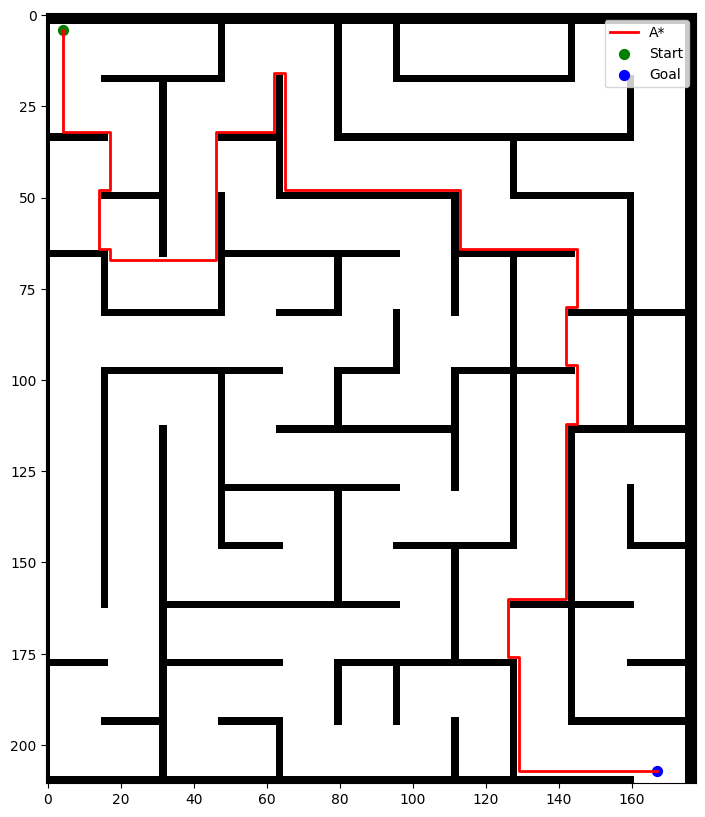

In [36]:
import itertools

class Node:
    def __init__(self, x, y, cost, parent):
        self.x = x
        self.y = y
        self.cost = cost
        self.parent = parent

def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def reconstruct_path(came_from, current):
    path = [current]
    while current in came_from:
        current = came_from[current]
        path.append(current)
    return path[::-1]

def a_star(grid, start, goal):
    h, w = grid.shape
    step = 1
    open_list = []
    counter = itertools.count()
    g_score = {start: 0}
    came_from = {}
    closed_set = set()

    heapq.heappush(open_list, (heuristic(start, goal), next(counter), start))

    neighbors = [(0,step),(step,0),(0,-step),(-step,0)]
    i = 0
    while open_list:
        i += 1
        _, _, current = heapq.heappop(open_list)
        if current in closed_set:
            continue
        if current == goal:
            return reconstruct_path(came_from, current), i
        closed_set.add(current)
        cx, cy = current

        for dx, dy in neighbors:
            nx, ny = cx + dx, cy + dy
            if nx < 0 or ny < 0 or nx >= w or ny >= h:
                continue
            if grid[ny, nx] == 1:
                continue
            tentative_g = g_score[current] + 1
            if tentative_g < g_score.get((nx, ny), float("inf")):
                g_score[(nx, ny)] = tentative_g
                came_from[(nx, ny)] = current
                f = tentative_g + heuristic((nx, ny), goal)
                heapq.heappush(open_list, (f, next(counter), (nx, ny)))
    return reconstruct_path(came_from, current)

path_a_star, a_star_iter = a_star(grid, start, goal)
print("Длина пути A*:", len(path_a_star) if path_a_star else "Путь не найден")

plt.figure(figsize=(10,10))
plt.imshow(grid, cmap='gray_r')

if path_a_star:
    px, py = zip(*path_a_star)
    print("end point: ", px[-1], py[-1])
    plt.plot(px, py, '-r', linewidth=2, label='A*')

plt.scatter([start[0]], [start[1]], c='green', s=50, label='Start')
plt.scatter([goal[0]], [goal[1]], c='blue', s=50, label='Goal')
plt.legend()
plt.show()

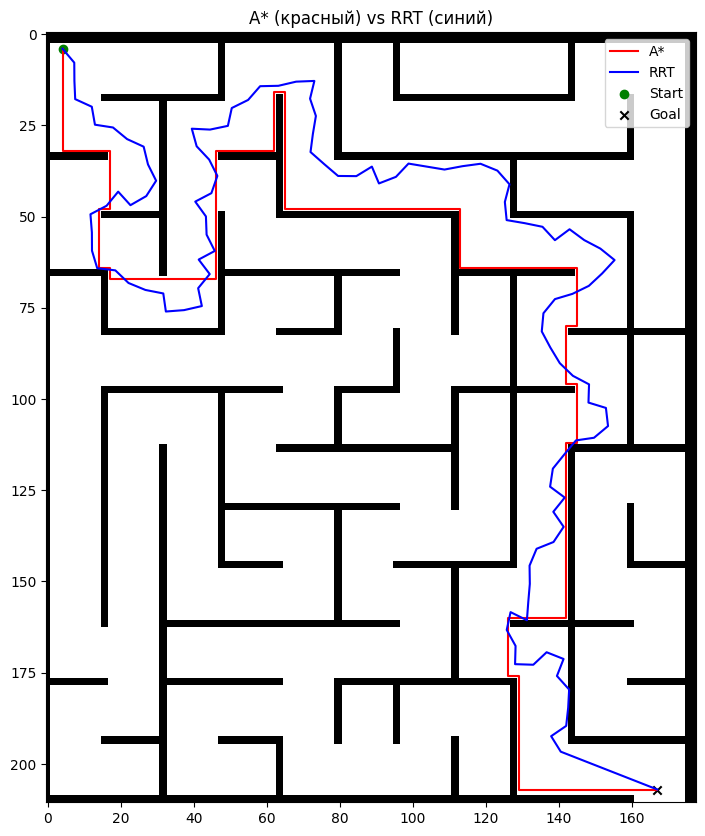

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(grid, cmap='gray_r')

# A* path
if path_a_star:
    px, py = zip(*path_a_star)
    plt.plot(px, py, "-r", label="A*")

# RRT path
if path_rrt:
    px, py = zip(*path_rrt)
    plt.plot(px, py, "-b", label="RRT")

plt.scatter(start[0], start[1], marker="o", color="green", label="Start")
plt.scatter(goal[0], goal[1], marker="x", color="black", label="Goal")
plt.legend()
plt.title("A* (красный) vs RRT (синий)")
plt.show()

# RRT* алгоритм

In [27]:
import random
import math

frames = []

class RRTStarNode:
    def __init__(self, x, y, parent=None):
        self.x = x
        self.y = y
        self.parent = parent
        self.cost = 0


def distance(n1, n2):
    return math.hypot(n1.x - n2.x, n1.y - n2.y)


def get_random_free():
    y, x = free_points[random.randint(0, len(free_points)-1)]
    return (x, y)


def nearest(tree, point):
    return min(tree, key=lambda n: math.hypot(n.x - point[0], n.y - point[1]))


def near(tree, new_node, radius):
    nodes = []
    for node in tree:
        if math.hypot(node.x - new_node.x, node.y - new_node.y) <= radius:
            nodes.append(node)
    return nodes


def steer(from_node, to_point, step_size):
    theta = math.atan2(to_point[1] - from_node.y, to_point[0] - from_node.x)
    new_x = from_node.x + step_size * math.cos(theta)
    new_y = from_node.y + step_size * math.sin(theta)
    return new_x, new_y


def build_path(node):
    path = []
    while node:
        path.append((node.x, node.y))
        node = node.parent
    return path[::-1]



def collision_point(x, y):
    if x < 0 or y < 0 or x >= width or y >= height:
        return True
    return grid[int(y)][int(x)] == 1

def collision_line(x1, y1, x2, y2):
    steps = int(max(abs(x2 - x1), abs(y2 - y1)))
    if steps == 0:
        return collision_point(int(x1), int(y1))
    for i in range(steps + 1):
        t = i / steps
        x = x1 + (x2 - x1) * t
        y = y1 + (y2 - y1) * t
        if collision_point(int(x), int(y)):
            return True
    return False

def rrt_star(start, goal, max_iter=10000, step_size=10, radius=10, goal_sample_rate=0.1):
    tree = [RRTStarNode(start[0], start[1])]

    for i in range(max_iter):
        #сохраняем поиск пути
        if i % 200 == 0:
          fig, ax = plt.subplots(figsize=(6,6))
          ax.imshow(grid, cmap='gray_r')

          for node in tree:
              if node.parent:
                  ax.plot([node.x, node.parent.x],
                          [node.y, node.parent.y],
                          color='blue', linewidth=0.5)

          ax.scatter(start[0], start[1], c='green')
          ax.scatter(goal[0], goal[1], c='red')

          ax.set_title(f"RRT iteration {i}")

          fig.canvas.draw()

          # сохраняем кадр
          canvas = fig.canvas
          canvas.draw()
          w, h = canvas.get_width_height()
          buf = np.frombuffer(canvas.buffer_rgba(), dtype=np.uint8)
          frame = buf.reshape((h, w, 4))
          frame = frame[:, :, :3]
          frames.append(frame)
          frames.append(frame)

          plt.close(fig)

        if random.random() < goal_sample_rate:
            rnd = goal
        else:
            rnd = get_random_free()

        nearest_node = nearest(tree, rnd)

        new_x, new_y = steer(nearest_node, rnd, step_size)

        if collision_line(nearest_node.x, nearest_node.y, new_x, new_y):
            continue

        new_node = RRTStarNode(new_x, new_y)

        neighbors = near(tree, new_node, radius)

        best_parent = nearest_node
        best_cost = nearest_node.cost + math.hypot(new_x - nearest_node.x, new_y - nearest_node.y)

        for node in neighbors:
            if collision_line(node.x, node.y, new_x, new_y):
                continue
            cost = node.cost + math.hypot(new_x - node.x, new_y - node.y)
            if cost < best_cost:
                best_parent = node
                best_cost = cost

        new_node.parent = best_parent
        new_node.cost = best_cost
        tree.append(new_node)

        for node in neighbors:
            if collision_line(new_node.x, new_node.y, node.x, node.y):
                continue
            new_cost = new_node.cost + math.hypot(node.x - new_node.x, node.y - new_node.y)
            if new_cost < node.cost:
                node.parent = new_node
                node.cost = new_cost

        # достижение цели
        if math.hypot(new_x - goal[0], new_y - goal[1]) < step_size:
            if not collision_line(new_x, new_y, goal[0], goal[1]):
                goal_node = RRTStarNode(goal[0], goal[1], new_node)
                return build_path(goal_node), frames, i

    return None

path_rrt_star, frames, rrt_star_iterations = rrt_star(start, goal)

print("RRT* найден путь:", path_rrt_star is not None)

RRT* найден путь: True


In [28]:
import imageio

imageio.mimsave("rrt_star.mp4", frames, fps=10)

from IPython.display import Video

Video("rrt_star.mp4", embed=True)

In [16]:
def smooth_path(path):
    if not path:
        return None

    smoothed = [path[0]]
    i = 0

    while i < len(path) - 1:
        j = len(path) - 1

        while j > i + 1:
            if not collision_line(path[i][0], path[i][1],
                                  path[j][0], path[j][1]):
                break
            j -= 1

        smoothed.append(path[j])
        i = j

    return smoothed

path_rrt_smooth = smooth_path(path_rrt_star)

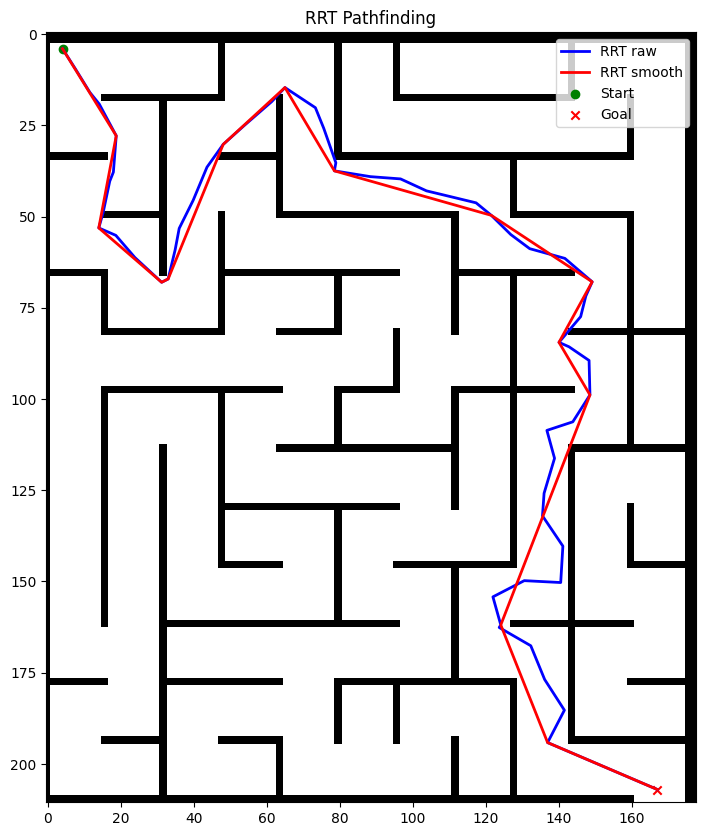

In [18]:
plt.figure(figsize=(10,10))
plt.imshow(grid, cmap='gray_r')

# rrt* путь
if path_rrt_star:
    px, py = zip(*path_rrt_star)
    plt.plot(px, py, '-b', linewidth=2, label='RRT raw')

#сглаженный rrt*
if path_rrt_smooth:
    px, py = zip(*path_rrt_smooth)
    plt.plot(px, py, '-r', linewidth=2, label='RRT smooth')

plt.scatter(start[0], start[1], marker="o", color="green", label="Start")
plt.scatter(goal[0], goal[1], marker="x", color="red", label="Goal")
plt.title("RRT Pathfinding")
plt.legend()
plt.show()

In [37]:
import time
import math

def path_length(path):
    if not path:
        return float('inf')
    length = 0
    for i in range(1, len(path)):
        length += math.hypot(path[i][0] - path[i-1][0],
                             path[i][1] - path[i-1][1])
    return length

start_time = time.time()
path_a_star, a_star_iter = a_star(grid, start, goal)
time_a_star = time.time() - start_time
len_a_star = path_length(path_a_star)
nodes_a_star = len(path_a_star)

start_time = time.time()
path_rrt, rrt_iter = rrt(start, goal)
time_rrt = time.time() - start_time
len_rrt = path_length(path_rrt)
nodes_rrt = len(path_rrt)

start_time = time.time()
path_rrt_star, frames, rrt_star_iter = rrt_star(start, goal)
time_rrt_star = time.time() - start_time
len_rrt_star = path_length(path_rrt_star)
nodes_rrt_star = len(path_rrt_star)

print(f"{'Алгоритм':<10} | {'Длина пути':<10} | {'Время (с)':<10} | {'Узлы/точки':<10}")
print("-"*50)
print(f"{'A*':<10} | {len_a_star:<10.2f} | {time_a_star:<10.4f} | {nodes_a_star:<10} (шаг=1)")
print(f"{'RRT':<10} | {len_rrt:<10.2f} | {time_rrt:<10.4f} | {nodes_rrt:<10} (шаг=5)")
print(f"{'RRT*':<10} | {len_rrt_star:<10.2f} | {time_rrt_star:<10.4f} | {nodes_rrt_star:<10} (шаг=10)")

Алгоритм   | Длина пути | Время (с)  | Узлы/точки
--------------------------------------------------
A*         | 518.00     | 0.0732     | 519        (шаг=1)
RRT        | 573.54     | 82.9821    | 59         (шаг=5)
RRT*       | 429.38     | 72.9911    | 58         (шаг=10)
